# 3D KLT particle picking on the TomoTwin 2df7 simulation

This notebook follows the full algorithm manually, in the spirit of
`notebooks/spheres.ipynb`. It intentionally does **not** call
`KLTParticleDetector3D.process_tomogram()`.

We inspect:

1. the realistic TomoTwin reconstruction and 2df7 ground truth;
2. non-overlapping patches and their variance distribution;
3. patch PSDs, radial averaging, ALS, and variance calibration;
4. prewhitening and the second PSD/RPSD estimate;
5. Fredholm eigenvalues/eigenfunctions across angular orders;
6. complete spherical-harmonic template multiplets;
7. the likelihood score volume;
8. diameter-scale NMS and one-to-one ground-truth evaluation.

The default `128^3` ROI contains realistic missing-wedge/noise artifacts,
other protein classes, vesicles, and fiducials. Change `ROI_START_ZYX` and
`ROI_SIZE` to investigate other regions or expand to the full volume.

In [1]:
from pathlib import Path
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import mrcfile
import numpy as np
import pandas as pd
import scipy
from scipy.optimize import linear_sum_assignment

from scipy.spatial.distance import cdist

from kltpicker_3d.alt_least_squares import alternating_least_squares_solver
from kltpicker_3d.fredholm_solver import solve_radial_fredholm_equation
from kltpicker_3d.spectral_estimation import estimate_isotropic_powerspectrum_tensor
from kltpicker_3d.utils import (
    calibrate_radial_psds,
    expand_spherical_harmonic_templates,
    generate_uniform_radial_sampling_points,
    prewhiten_tomogram,
    radial_average_jax,
    ranked_local_maxima_nms_3d,
    radial_mode_truncation_index,
    radial_psd_to_variance,
    trigonometric_interpolation,
)

jax.config.update("jax_platform_name", "cpu")
plt.rcParams.update({
    "figure.figsize": (8, 4),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "image.cmap": "gray",
})
print("JAX devices:", jax.devices())

JAX devices: [CpuDevice(id=0)]


## Configuration

TomoTwin reports a 33-voxel box for 2df7. At 10.204 Å/voxel this is about
337 Å. Geometry below is kept explicitly in voxel units.

In [2]:
DATA_DIR = Path("data/tomotwin_2df7")
TOMOGRAM_PATH = DATA_DIR / "tiltseries_rec.mrc"
POSITIONS_PATH = DATA_DIR / "particle_positions.txt"

TARGET_CLASS = "2df7"
PARTICLE_DIAMETER_VOXELS = 33
PATCH_FRACTION = 0.8
TEMPLATE_FRACTION = 0.8
BANDLIMIT = np.pi

ROI_START_ZYX = np.array([24, 16, 304])
ROI_SIZE = 128

LEGENDRE_ORDER = 40
MAX_ANGULAR_ORDER = 4
ALS_MAX_ITER = 500
ENERGY_FRACTION = 0.99
# Diagnostic assumption: the number of fully evaluable 2df7 particles is known.
KNOWN_PARTICLE_COUNT = 7
MATCH_TOLERANCE = PARTICLE_DIAMETER_VOXELS / 2

assert TOMOGRAM_PATH.exists(), f"Missing {TOMOGRAM_PATH}"
assert POSITIONS_PATH.exists(), f"Missing {POSITIONS_PATH}"

def odd_floor(value):
    value = int(np.floor(value))
    return value if value % 2 else value - 1

PATCH_SIZE = odd_floor(PATCH_FRACTION * PARTICLE_DIAMETER_VOXELS)
TEMPLATE_SIZE = odd_floor(TEMPLATE_FRACTION * PARTICLE_DIAMETER_VOXELS)
TEMPLATE_RADIUS = (TEMPLATE_SIZE - 1) / 2
SPECTRUM_SIZE = 2 * PATCH_SIZE - 1

print({
    "particle_diameter_voxels": PARTICLE_DIAMETER_VOXELS,
    "patch_size": PATCH_SIZE,
    "template_size": TEMPLATE_SIZE,
    "template_radius": TEMPLATE_RADIUS,
    "spectrum_size": SPECTRUM_SIZE,
})

{'particle_diameter_voxels': 33, 'patch_size': 25, 'template_size': 25, 'template_radius': 12.0, 'spectrum_size': 49}


## Load the reconstruction and ground truth

MRC arrays are indexed `(z, y, x)`, while `particle_positions.txt` stores
`(x, y, z)`. We convert coordinates once and use `(z, y, x)` everywhere.

In [3]:
with mrcfile.open(TOMOGRAM_PATH, permissive=True) as mrc:
    full_tomogram = np.asarray(mrc.data, dtype=np.float32)
    voxel_size_xyz = np.array([
        float(mrc.voxel_size.x),
        float(mrc.voxel_size.y),
        float(mrc.voxel_size.z),
    ])

columns = ["class", "x", "y", "z", "rot1", "rot2", "rot3"]
positions = pd.read_csv(POSITIONS_PATH, header=None, names=columns)
target_xyz = positions.loc[
    positions["class"].str.lower() == TARGET_CLASS.lower(),
    ["x", "y", "z"],
].to_numpy()
target_zyx = target_xyz[:, ::-1]

print("Tomogram shape (z,y,x):", full_tomogram.shape)
print("Voxel size (x,y,z), Å:", voxel_size_xyz)
print("Intensity mean/std:", full_tomogram.mean(), full_tomogram.std())
display(positions.groupby("class").size().rename("count").to_frame())

Tomogram shape (z,y,x): (200, 512, 512)
Voxel size (x,y,z), Å: [10.20408154 10.20408154 10.20408154]
Intensity mean/std: 21.00976 67.50868


,count
class,
1avo,91
1e9r,93
1fpy,97
1fzg,93
1jz8,91
1oao,94
2df7,100
fiducial,8
vesicle,4


In [4]:
roi_stop = ROI_START_ZYX + ROI_SIZE
roi_slices = tuple(slice(int(a), int(b)) for a, b in zip(ROI_START_ZYX, roi_stop))
tomogram = full_tomogram[roi_slices].copy()

inside_roi = np.all(
    (target_zyx >= ROI_START_ZYX) & (target_zyx < roi_stop),
    axis=1,
)
gt_all = target_zyx[inside_roi] - ROI_START_ZYX

margin = PARTICLE_DIAMETER_VOXELS / 2
evaluable = np.all(
    (gt_all >= margin) & (gt_all < ROI_SIZE - margin),
    axis=1,
)
gt = gt_all[evaluable]
assert len(gt) == KNOWN_PARTICLE_COUNT, (
    f"Expected {KNOWN_PARTICLE_COUNT} evaluable particles, found {len(gt)}. "
    "Update the known count if the ROI changes."
)

print("ROI:", tuple(ROI_START_ZYX), "to", tuple(roi_stop))
print("2df7 centers in ROI:", len(gt_all))
print("Fully evaluable centers:", len(gt))

ROI: (np.int64(24), np.int64(16), np.int64(304)) to (np.int64(152), np.int64(144), np.int64(432))
2df7 centers in ROI: 12
Fully evaluable centers: 7


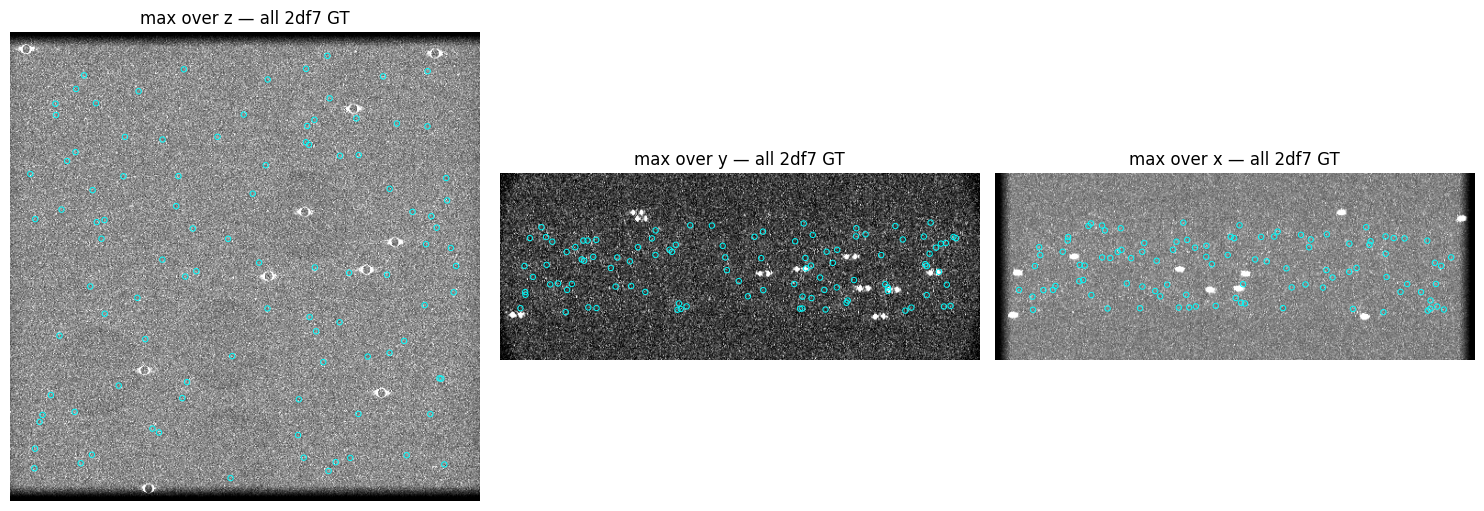

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
projections = [
    (full_tomogram.max(axis=0), target_zyx[:, [2, 1]], "max over z", (2, 1)),
    (full_tomogram.max(axis=1), target_zyx[:, [2, 0]], "max over y", (2, 0)),
    (full_tomogram.max(axis=2), target_zyx[:, [1, 0]], "max over x", (1, 0)),
]
for ax, (image, points, title, _) in zip(axes, projections):
    lo, hi = np.percentile(image, [2, 99.5])
    ax.imshow(image, vmin=lo, vmax=hi)
    ax.scatter(points[:, 0], points[:, 1], s=15, facecolors="none",
               edgecolors="cyan", linewidths=0.7)
    ax.set_title(title + " — all 2df7 GT")
    ax.axis("off")
plt.tight_layout()

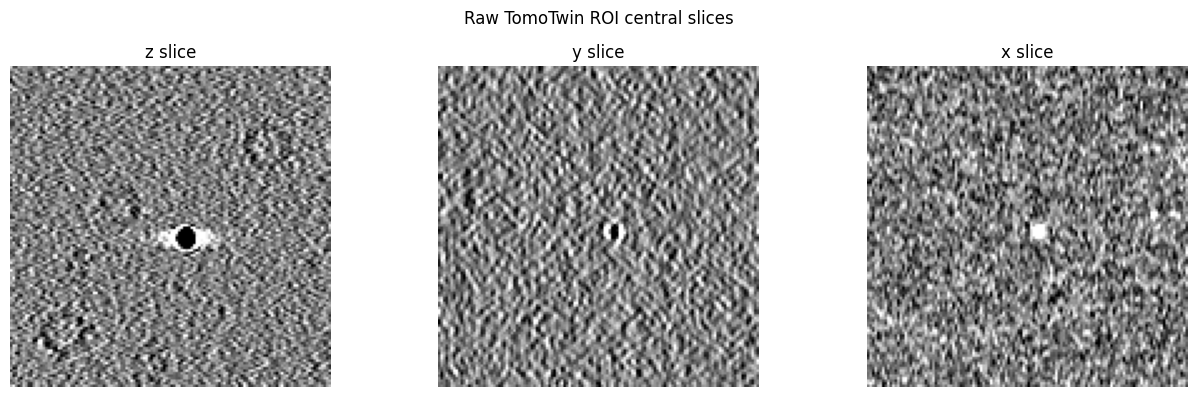

In [6]:
mid = ROI_SIZE // 2
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, image, title in zip(
    axes,
    [tomogram[mid], tomogram[:, mid], tomogram[:, :, mid]],
    ["z slice", "y slice", "x slice"],
):
    lo, hi = np.percentile(image, [1, 99])
    ax.imshow(image, vmin=lo, vmax=hi)
    ax.set_title(title)
    ax.axis("off")
plt.suptitle("Raw TomoTwin ROI central slices")
plt.tight_layout()

## Patch extraction and first-pass spectrum estimation

Patches are extracted independently along all three axes. This is important
for rectangular tomograms; using only `min(shape)` would discard most data.

In [7]:
def extract_nonoverlapping_patches(volume, patch_size):
    blocks = np.array(volume.shape) // patch_size
    cropped_shape = blocks * patch_size
    cropped = volume[
        :cropped_shape[0],
        :cropped_shape[1],
        :cropped_shape[2],
    ]
    bz, by, bx = blocks
    patches = cropped.reshape(
        bz, patch_size, by, patch_size, bx, patch_size
    ).transpose(0, 2, 4, 1, 3, 5)
    return patches.reshape(-1, patch_size, patch_size, patch_size), blocks

uniform_points, shell_ids, shell_counts = (
    generate_uniform_radial_sampling_points(SPECTRUM_SIZE, BANDLIMIT)
)

vect_spectrum_estimation = jax.vmap(
    estimate_isotropic_powerspectrum_tensor,
    in_axes=(0, None),
)
vect_radial_average = jax.vmap(
    radial_average_jax,
    in_axes=(0, None, None, None),
)

def estimate_and_calibrate(volume):
    patches, blocks = extract_nonoverlapping_patches(volume, PATCH_SIZE)
    centered = jnp.asarray(patches) - jnp.mean(
        jnp.asarray(patches), axis=(1, 2, 3), keepdims=True
    )
    variances = np.asarray(jnp.var(centered, axis=(1, 2, 3)))
    noise_count = max(1, int(np.floor(0.25 * variances.size)))
    noise_variance = float(np.mean(np.sort(variances)[:noise_count]))
    mean_variance = float(np.mean(variances))

    max_distance = int(np.floor(0.3 * PATCH_SIZE))
    psds = vect_spectrum_estimation(centered, max_distance)
    rblocks = vect_radial_average(
        psds, shell_ids, shell_counts, uniform_points.size
    )
    factorization = alternating_least_squares_solver(
        rblocks, ALS_MAX_ITER, 1e-4
    )
    particle_psd, noise_psd = calibrate_radial_psds(
        uniform_points,
        factorization.gamma,
        factorization.v,
        noise_variance,
        mean_variance,
    )
    return {
        "patches": np.asarray(patches),
        "blocks": blocks,
        "centered": centered,
        "variances": variances,
        "noise_variance": noise_variance,
        "mean_variance": mean_variance,
        "psds": np.asarray(psds),
        "rblocks": np.asarray(rblocks),
        "factorization": factorization,
        "particle_psd": particle_psd,
        "noise_psd": noise_psd,
    }

start = time.perf_counter()
first = estimate_and_calibrate(tomogram)
print(f"First PSD pass: {time.perf_counter() - start:.2f} s")
print("Patch blocks:", first["blocks"], "number of patches:", len(first["patches"]))
print("Noise variance:", first["noise_variance"])
print("Mean patch variance:", first["mean_variance"])

First PSD pass: 3.67 s
Patch blocks: [5 5 5] number of patches: 125
Noise variance: 4568.15283203125
Mean patch variance: 4939.2451171875


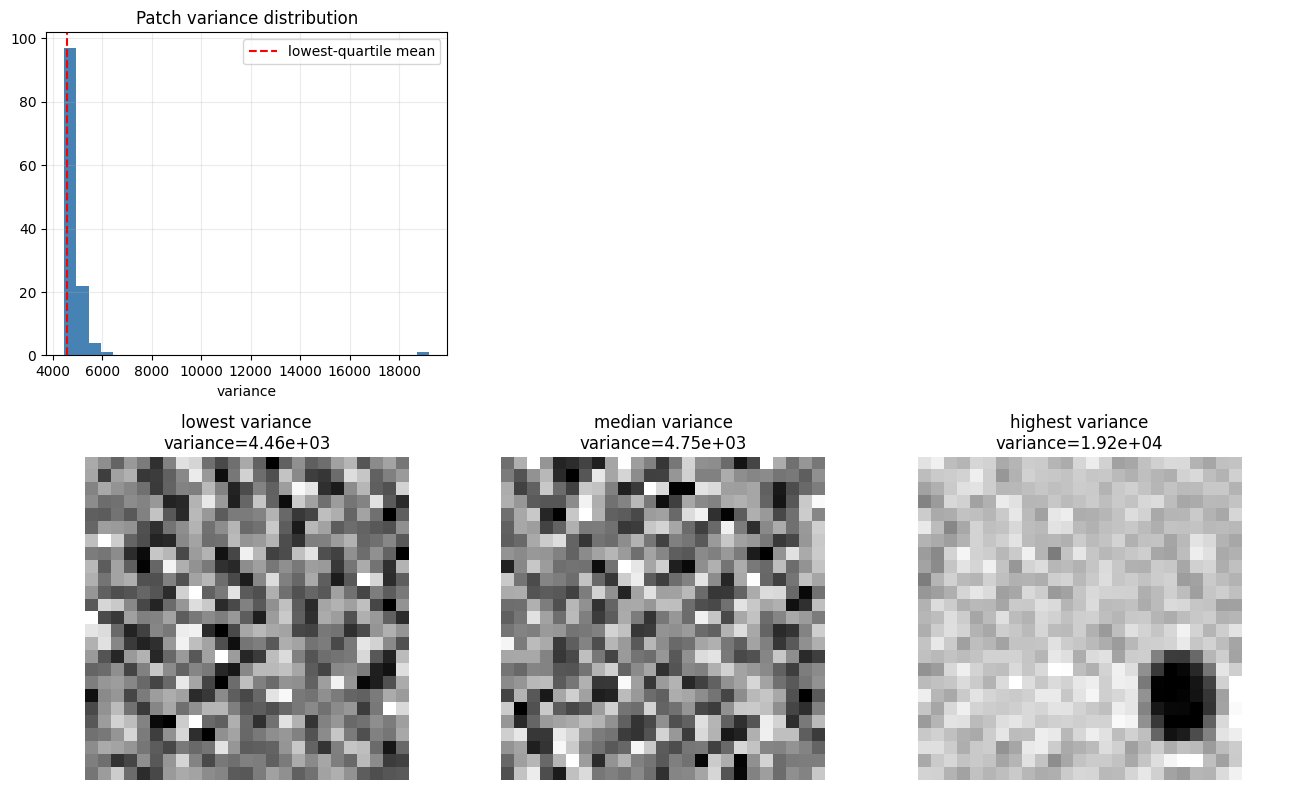

In [8]:
order = np.argsort(first["variances"])
chosen = [order[0], order[len(order)//2], order[-1]]
labels = ["lowest variance", "median variance", "highest variance"]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes[0, 0].hist(first["variances"], bins=30, color="steelblue")
axes[0, 0].axvline(first["noise_variance"], color="red", ls="--",
                   label="lowest-quartile mean")
axes[0, 0].set_title("Patch variance distribution")
axes[0, 0].legend()
axes[0, 0].set_xlabel("variance")
for col, (idx, label) in enumerate(zip(chosen, labels)):
    patch = first["patches"][idx]
    image = patch[PATCH_SIZE // 2]
    lo, hi = np.percentile(image, [1, 99])
    axes[1, col].imshow(image, vmin=lo, vmax=hi)
    axes[1, col].set_title(f"{label}\nvariance={first['variances'][idx]:.3g}")
    axes[1, col].axis("off")
for ax in axes[0, 1:]:
    ax.axis("off")
plt.tight_layout()

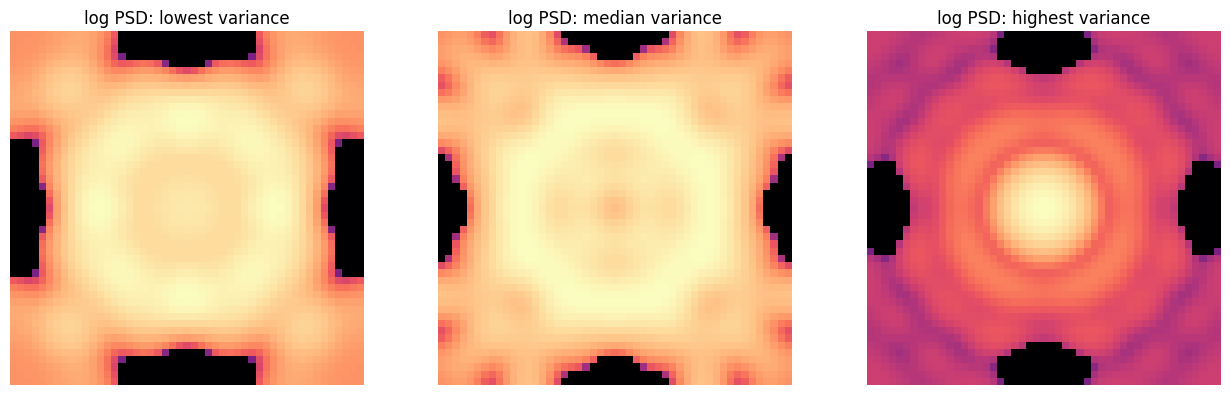

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
psd_mid = SPECTRUM_SIZE // 2
for ax, idx, label in zip(axes, chosen, labels):
    image = np.log1p(first["psds"][idx, psd_mid])
    ax.imshow(image, cmap="magma")
    ax.set_title(f"log PSD: {label}")
    ax.axis("off")
plt.tight_layout()

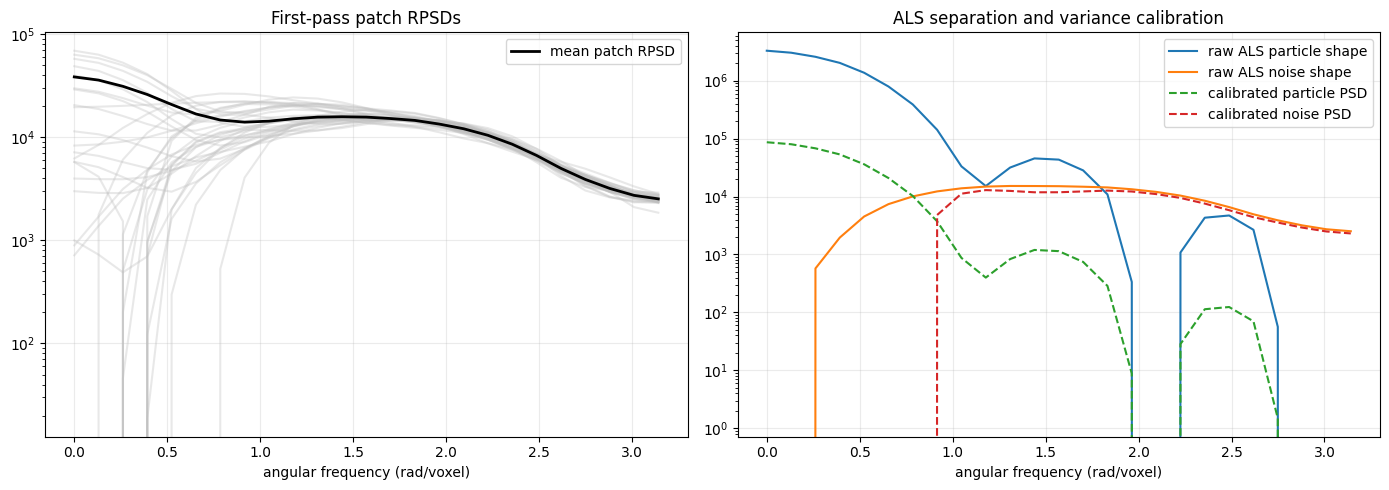

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for curve in first["rblocks"][::max(1, len(first["rblocks"]) // 30)]:
    axes[0].plot(uniform_points, curve, color="0.75", alpha=0.35)
axes[0].plot(uniform_points, first["rblocks"].mean(axis=0),
             color="black", lw=2, label="mean patch RPSD")
axes[0].set_yscale("log")
axes[0].set_title("First-pass patch RPSDs")
axes[0].set_xlabel("angular frequency (rad/voxel)")
axes[0].legend()

axes[1].plot(uniform_points, np.asarray(first["factorization"].gamma),
             label="raw ALS particle shape")
axes[1].plot(uniform_points, np.asarray(first["factorization"].v),
             label="raw ALS noise shape")
axes[1].plot(uniform_points, first["particle_psd"], "--",
             label="calibrated particle PSD")
axes[1].plot(uniform_points, first["noise_psd"], "--",
             label="calibrated noise PSD")
axes[1].set_yscale("log")
axes[1].set_title("ALS separation and variance calibration")
axes[1].set_xlabel("angular frequency (rad/voxel)")
axes[1].legend()
plt.tight_layout()

In [11]:
print("Integrated calibrated particle variance:",
      radial_psd_to_variance(uniform_points, first["particle_psd"]))
print("Measured signal variance:",
      first["mean_variance"] - first["noise_variance"])
print("Integrated calibrated noise variance:",
      radial_psd_to_variance(uniform_points, first["noise_psd"]))
print("Measured noise variance:", first["noise_variance"])

Integrated calibrated particle variance: 371.09228515624994
Measured signal variance: 371.09228515625
Integrated calibrated noise variance: 4568.152832031249
Measured noise variance: 4568.15283203125


## Prewhitening and second-pass spectrum estimation

In [12]:
start = time.perf_counter()
whitened = prewhiten_tomogram(
    jnp.asarray(tomogram),
    uniform_points,
    first["noise_psd"],
)
jax.block_until_ready(whitened)
whitened_np = np.asarray(whitened)
print(f"Whitening: {time.perf_counter() - start:.2f} s")
print("Whitened mean/norm:", whitened_np.mean(), np.linalg.norm(whitened_np))

Whitening: 0.73 s
Whitened mean/norm: 1.0857093e-11 0.9999999


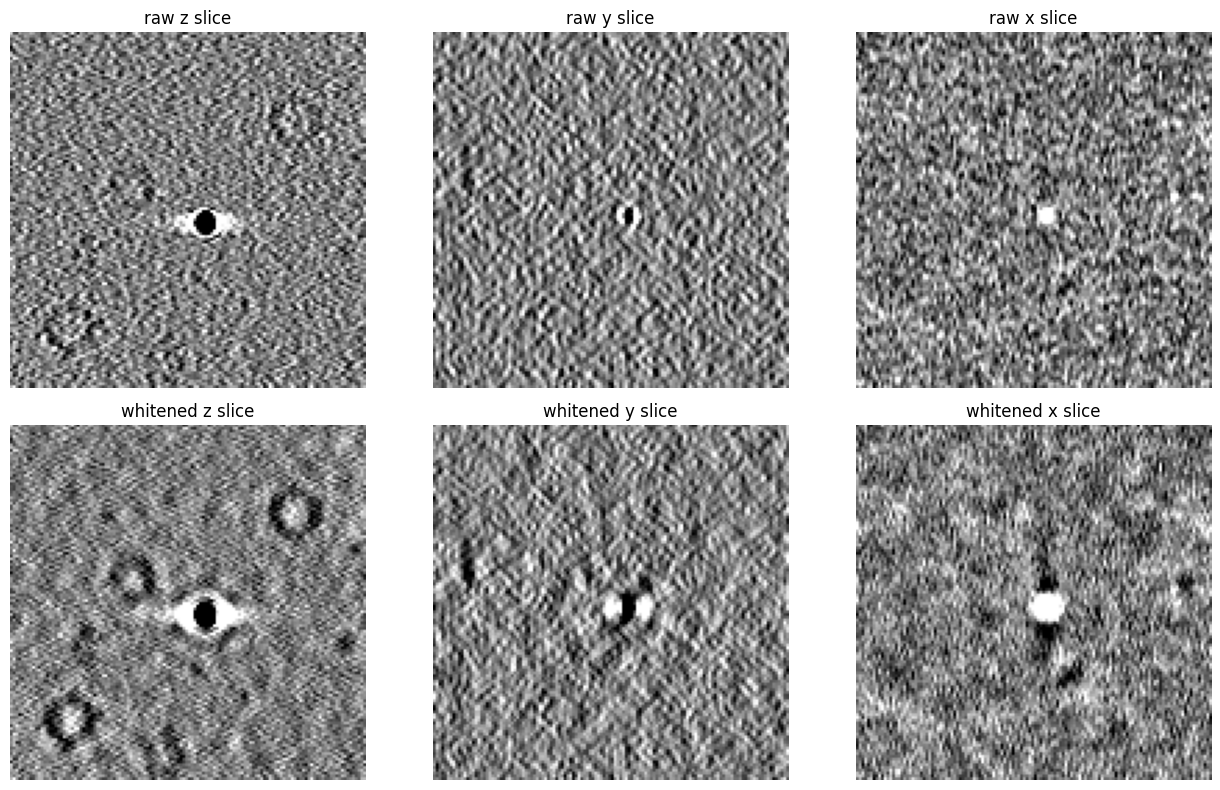

In [13]:
def robust_standardize(image):
    lo, hi = np.percentile(image, [1, 99])
    return np.clip((image - lo) / (hi - lo + 1e-12), 0, 1)

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
raw_slices = [tomogram[mid], tomogram[:, mid], tomogram[:, :, mid]]
white_slices = [whitened_np[mid], whitened_np[:, mid], whitened_np[:, :, mid]]
titles = ["z", "y", "x"]
for col in range(3):
    axes[0, col].imshow(robust_standardize(raw_slices[col]))
    axes[0, col].set_title(f"raw {titles[col]} slice")
    axes[1, col].imshow(robust_standardize(white_slices[col]))
    axes[1, col].set_title(f"whitened {titles[col]} slice")
    axes[0, col].axis("off")
    axes[1, col].axis("off")
plt.tight_layout()

In [14]:
start = time.perf_counter()
second = estimate_and_calibrate(whitened_np)
print(f"Second PSD pass: {time.perf_counter() - start:.2f} s")
print("Second-pass noise variance:", second["noise_variance"])

Second PSD pass: 0.43 s
Second-pass noise variance: 3.6032301409250067e-07


Noise PSD coefficient of variation before: 0.8364561146461619
Noise PSD coefficient of variation after: 1.1610624735256763
DIAGNOSTIC WARNING: the second-pass ALS noise estimate is not flatter. Whitening executed numerically, but the isotropic noise model or ALS separation should be investigated on this realistic tomogram.


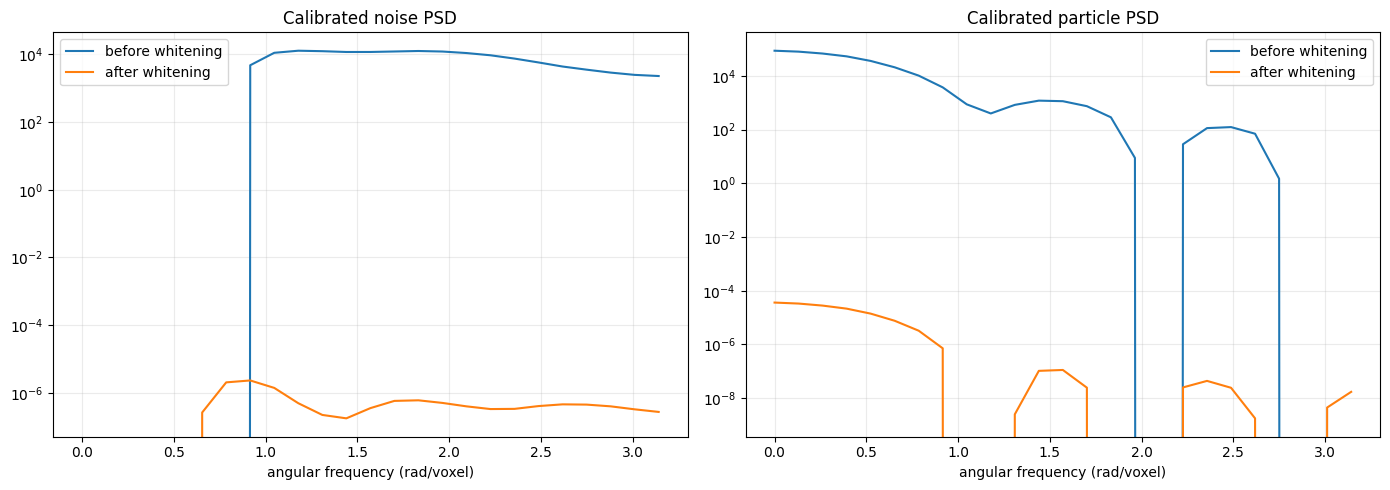

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(uniform_points, first["noise_psd"], label="before whitening")
axes[0].plot(uniform_points, second["noise_psd"], label="after whitening")
axes[0].set_yscale("log")
axes[0].set_title("Calibrated noise PSD")
axes[0].set_xlabel("angular frequency (rad/voxel)")
axes[0].legend()

axes[1].plot(uniform_points, first["particle_psd"], label="before whitening")
axes[1].plot(uniform_points, second["particle_psd"], label="after whitening")
axes[1].set_yscale("log")
axes[1].set_title("Calibrated particle PSD")
axes[1].set_xlabel("angular frequency (rad/voxel)")
axes[1].legend()
plt.tight_layout()

noise_flatness_before = np.std(first["noise_psd"]) / np.mean(first["noise_psd"])
noise_flatness_after = np.std(second["noise_psd"]) / np.mean(second["noise_psd"])
print("Noise PSD coefficient of variation before:", noise_flatness_before)
print("Noise PSD coefficient of variation after:", noise_flatness_after)
if noise_flatness_after >= noise_flatness_before:
    print(
        "DIAGNOSTIC WARNING: the second-pass ALS noise estimate is not flatter. "
        "Whitening executed numerically, but the isotropic noise model or ALS "
        "separation should be investigated on this realistic tomogram."
    )

## Fredholm equations across angular orders

Each eigenvalue is indexed by angular degree `ell` and radial index `n`.
Under isotropy it is independent of spherical-harmonic `m`, producing a
`(2 ell + 1)`-fold multiplet.

In [16]:
legendre_nodes, legendre_weights = scipy.special.roots_legendre(LEGENDRE_ORDER)
frequency_nodes = BANDLIMIT * (legendre_nodes + 1) / 2
Gx = np.maximum(
    np.asarray(
        trigonometric_interpolation(
            uniform_points,
            second["particle_psd"],
            frequency_nodes,
        )
    ),
    0,
)

eigvals_by_order = []
eigfuncs_by_order = []
quadrature_by_order = []
for ell in range(MAX_ANGULAR_ORDER):
    values, functions, W = solve_radial_fredholm_equation(
        Gx,
        ell,
        TEMPLATE_RADIUS,
        BANDLIMIT,
        K=LEGENDRE_ORDER,
    )
    eigvals_by_order.append(values)
    eigfuncs_by_order.append(functions)
    quadrature_by_order.append(W)

eigvals_matrix = np.asarray(eigvals_by_order)
eigfuncs_matrix = np.asarray(eigfuncs_by_order)

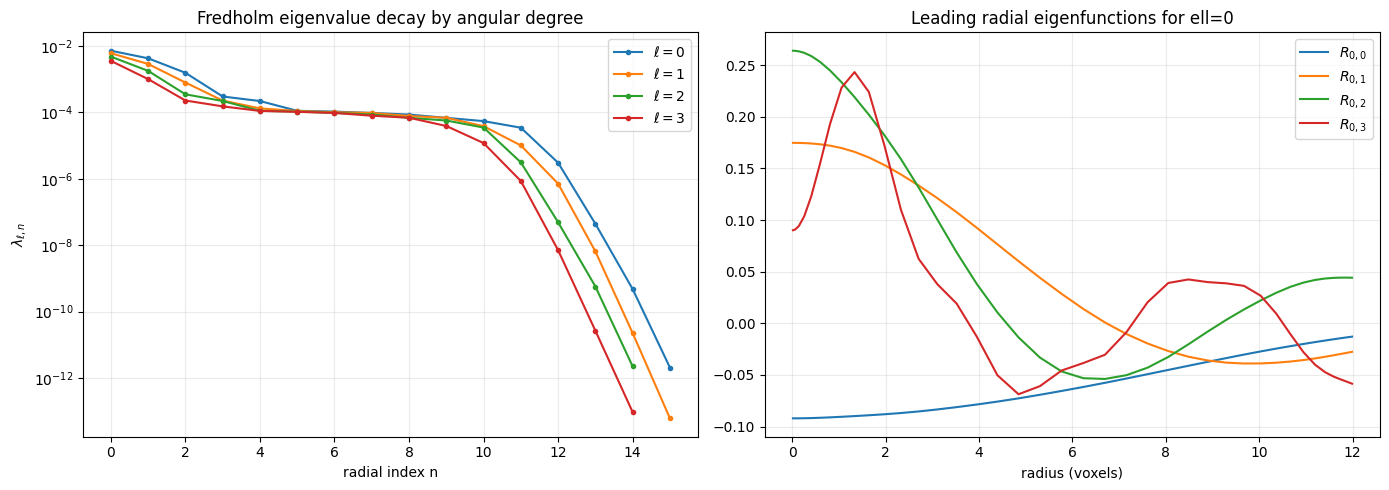

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ell in range(MAX_ANGULAR_ORDER):
    positive = eigvals_matrix[ell] > 0
    axes[0].semilogy(
        np.arange(LEGENDRE_ORDER)[positive],
        eigvals_matrix[ell, positive],
        marker=".",
        label=fr"$\ell={ell}$",
    )
axes[0].set_title("Fredholm eigenvalue decay by angular degree")
axes[0].set_xlabel("radial index n")
axes[0].set_ylabel(r"$\lambda_{\ell,n}$")
axes[0].legend()

spatial_nodes = TEMPLATE_RADIUS * (legendre_nodes + 1) / 2
for n in range(min(4, LEGENDRE_ORDER)):
    axes[1].plot(
        spatial_nodes,
        np.real(eigfuncs_matrix[0, :, n]),
        label=fr"$R_{{0,{n}}}$",
    )
axes[1].set_title("Leading radial eigenfunctions for ell=0")
axes[1].set_xlabel("radius (voxels)")
axes[1].legend()
plt.tight_layout()

In [18]:
flat_eigvals = eigvals_matrix.reshape(-1)
flat_eigfuncs = eigfuncs_matrix.transpose(0, 2, 1).reshape(-1, LEGENDRE_ORDER)
flat_orders = np.repeat(np.arange(MAX_ANGULAR_ORDER), LEGENDRE_ORDER)
flat_radial_indices = np.tile(np.arange(LEGENDRE_ORDER), MAX_ANGULAR_ORDER)

sort_idx = np.argsort(flat_eigvals)[::-1]
flat_eigvals = flat_eigvals[sort_idx]
flat_eigfuncs = flat_eigfuncs[sort_idx]
flat_orders = flat_orders[sort_idx]
flat_radial_indices = flat_radial_indices[sort_idx]

positive = flat_eigvals > np.spacing(1)
flat_eigvals = flat_eigvals[positive]
flat_eigfuncs = flat_eigfuncs[positive]
flat_orders = flat_orders[positive]
flat_radial_indices = flat_radial_indices[positive]

assert np.all(np.diff(flat_eigvals) <= 0)
display(pd.DataFrame({
    "lambda": flat_eigvals[:20],
    "ell": flat_orders[:20],
    "radial_n": flat_radial_indices[:20],
    "m_multiplicity": 2 * flat_orders[:20] + 1,
}))

,lambda,ell,radial_n,m_multiplicity
0,0.007234,0,0,1
1,0.006081,1,0,3
2,0.004809,2,0,5
3,0.004274,0,1,1
4,0.003579,3,0,7
5,0.002889,1,1,3
6,0.001786,2,1,5
7,0.001564,0,2,1
8,0.001009,3,1,7
9,0.000795,1,2,3


## Interpolate radial eigenfunctions and construct complete templates

In [19]:
truncate_idx = radial_mode_truncation_index(
    flat_eigvals,
    flat_orders,
    ENERGY_FRACTION,
)
eigvals = flat_eigvals[:truncate_idx]
eigfuncs = flat_eigfuncs[:truncate_idx]
orders = flat_orders[:truncate_idx]
radial_indices = flat_radial_indices[:truncate_idx]

radius_grid = np.arange(-(TEMPLATE_SIZE // 2), TEMPLATE_SIZE // 2 + 1)
Z, Y, X = np.meshgrid(radius_grid, radius_grid, radius_grid, indexing="ij")
r_tensor = np.sqrt(Z**2 + Y**2 + X**2)
rho_uniform, rho_inverse = np.unique(r_tensor, return_inverse=True)

rho_leg_a = TEMPLATE_RADIUS * (legendre_nodes + 1) / 2
rho_leg_c = BANDLIMIT * (legendre_nodes + 1) / 2
r_grid_uniform = np.outer(rho_uniform, rho_leg_c)
r_grid_legendre = np.outer(rho_leg_a, rho_leg_c)

def Hn(values, ell):
    return 4 * np.pi * (1j**ell) * scipy.special.spherical_jn(ell, values)

max_retained_order = int(orders.max()) + 1
H_uniform = np.asarray([
    Hn(r_grid_uniform, ell) for ell in range(max_retained_order)
])[orders]
H_legendre = np.asarray([
    Hn(r_grid_legendre, ell) for ell in range(max_retained_order)
])[orders]

frequency_measure = (
    BANDLIMIT / 2
    * legendre_weights
    * Gx
    * rho_leg_c**2
)
spatial_measure = (
    TEMPLATE_RADIUS / 2
    * legendre_weights
    * rho_leg_a**2
)
sign = np.where(orders % 2, -1, 1)
psi = (
    H_uniform * frequency_measure[None, None, :]
) @ (sign[:, None, None] * H_legendre)

eigfuncs_uniform = (
    np.einsum("bik,k,bk->bi", psi, spatial_measure, eigfuncs)
    / eigvals[:, None]
)
radial_templates = eigfuncs_uniform[:, rho_inverse].reshape(
    -1, TEMPLATE_SIZE, TEMPLATE_SIZE, TEMPLATE_SIZE
)

templates, template_radial_index, m_values = (
    expand_spherical_harmonic_templates(
        radial_templates,
        orders,
        Z,
        Y,
        X,
    )
)
template_eigvals = eigvals[template_radial_index]
template_orders = orders[template_radial_index]

print("Retained radial eigenpairs:", len(eigvals))
print("Expanded angular templates:", len(templates))
print("Orders/counts:", np.unique(template_orders, return_counts=True))

Retained radial eigenpairs: 37
Expanded angular templates: 147
Orders/counts: (array([0, 1, 2, 3]), array([ 9, 30, 45, 63]))


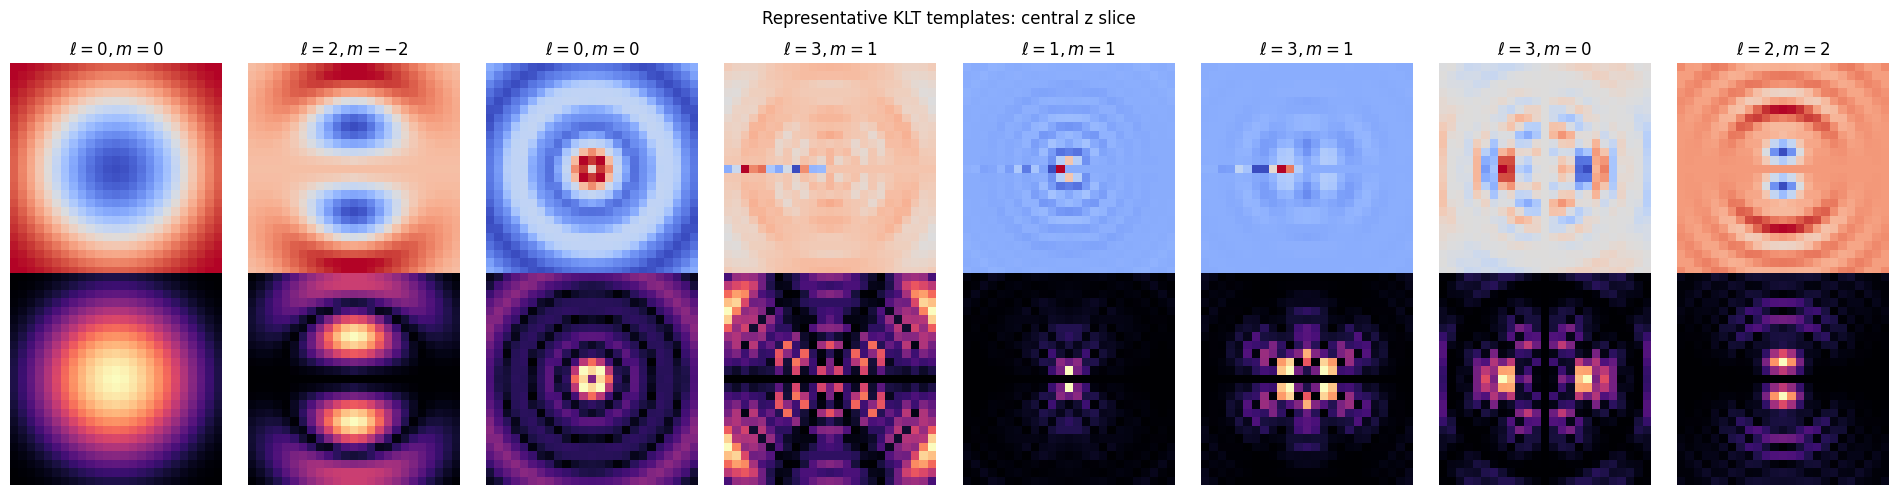

In [20]:
show = np.linspace(0, len(templates) - 1, min(8, len(templates))).astype(int)
fig, axes = plt.subplots(2, len(show), figsize=(2.4 * len(show), 5))
for col, template_idx in enumerate(show):
    center_slice = templates[template_idx, TEMPLATE_SIZE // 2]
    axes[0, col].imshow(np.real(center_slice), cmap="coolwarm")
    axes[0, col].set_title(
        fr"$\ell={template_orders[template_idx]},m={m_values[template_idx]}$"
    )
    axes[1, col].imshow(np.abs(center_slice), cmap="magma")
    axes[0, col].axis("off")
    axes[1, col].axis("off")
axes[0, 0].set_ylabel("real")
axes[1, 0].set_ylabel("magnitude")
plt.suptitle("Representative KLT templates: central z slice")
plt.tight_layout()

## Likelihood score volume

We now construct the low-rank covariance in the template span and correlate
each resulting likelihood kernel with the same whitened volume used for the
second PSD estimate.

In [21]:
n_templates = templates.shape[0]
template_voxels = TEMPLATE_SIZE**3
template_matrix = jnp.asarray(templates.reshape(n_templates, template_voxels).T)
Q, R = jnp.linalg.qr(template_matrix, mode="reduced")

noise_variance = second["noise_variance"]
H = (
    (R * jnp.asarray(template_eigvals)[None, :]) @ jnp.conj(R.T)
    + noise_variance * jnp.eye(R.shape[0])
)
H_eigvals, P = jnp.linalg.eigh(H)
D = (1 / noise_variance) - (1 / H_eigvals)
mu = jnp.linalg.slogdet(H / noise_variance)[1]

D = D[::-1]
P = P[:, ::-1]
B = Q @ P
kernels = B.T.reshape(-1, TEMPLATE_SIZE, TEMPLATE_SIZE, TEMPLATE_SIZE)

score_shape = tuple(np.array(tomogram.shape) - TEMPLATE_SIZE + 1)
score_init = jnp.zeros(score_shape, dtype=jnp.float32)

def score_body(i, score):
    kernel = jnp.conj(jnp.flip(kernels[i], axis=(0, 1, 2)))
    response = jax.scipy.signal.fftconvolve(
        whitened,
        kernel,
        mode="valid",
    )
    return score + D[i] * jnp.abs(response)**2

start = time.perf_counter()
score = jax.lax.fori_loop(0, kernels.shape[0], score_body, score_init) - mu
score_np = np.asarray(score)
print(f"Likelihood scoring: {time.perf_counter() - start:.2f} s")
print("Score shape:", score_np.shape)
print("Score min/max:", score_np.min(), score_np.max())
assert np.isfinite(score_np).all()

Likelihood scoring: 5.38 s
Score shape: (104, 104, 104)
Score min/max: -668.96045 381890.94


<Axes: title={'center': 'Likelihood-score distribution'}, xlabel='Likelihood score', ylabel='Number of voxels'>

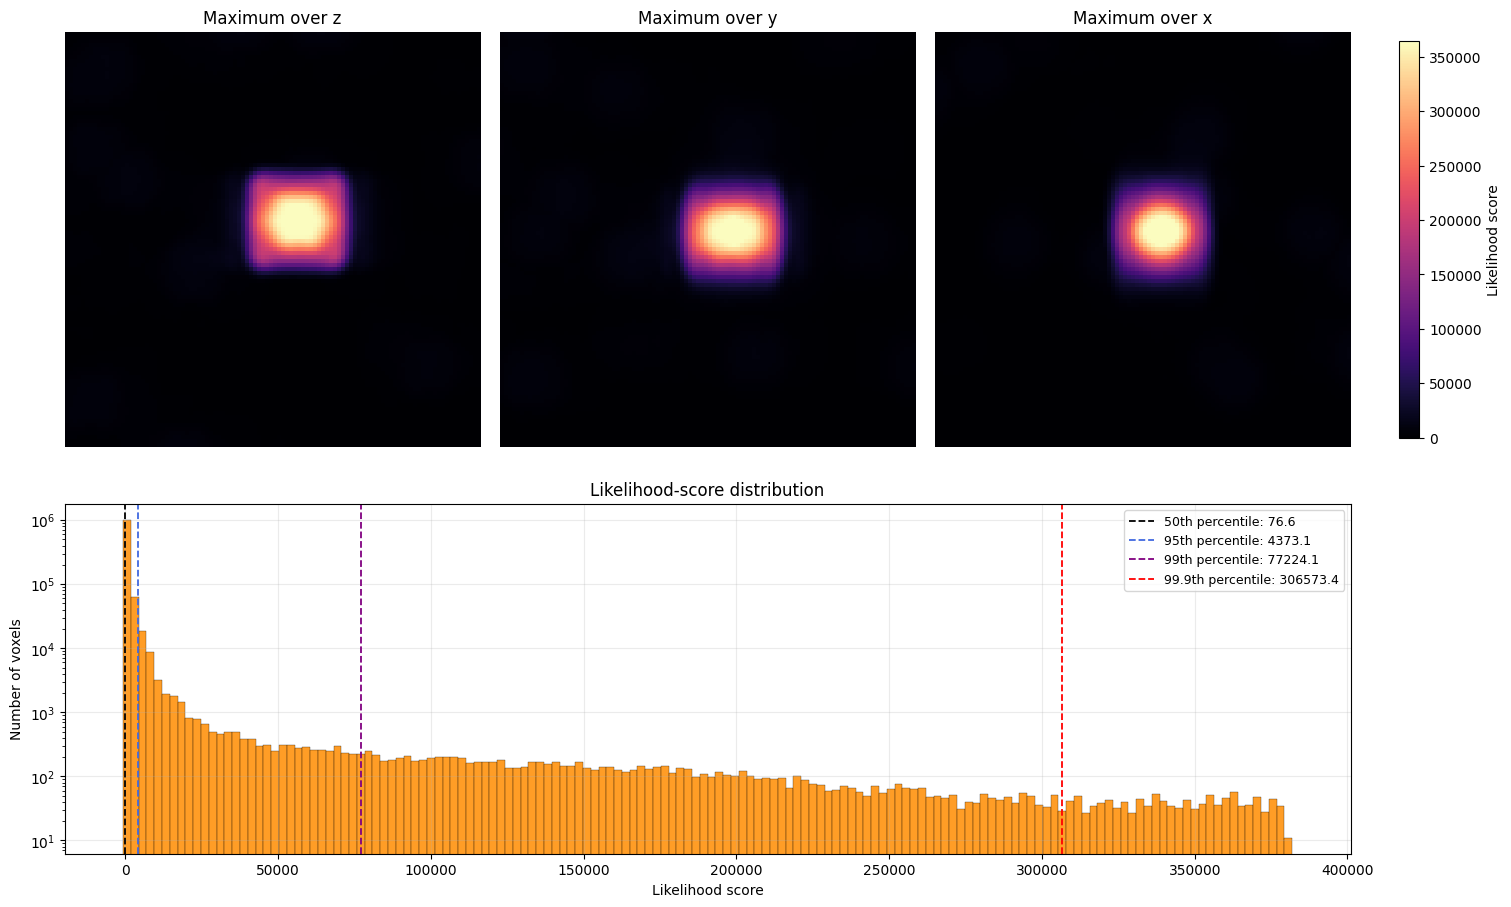

In [22]:
score_projections = [
    score_np.max(axis=0),
    score_np.max(axis=1),
    score_np.max(axis=2),
]
projection_titles = [
    "Maximum over z",
    "Maximum over y",
    "Maximum over x",
]

fig = plt.figure(figsize=(15, 9), constrained_layout=True)
grid = fig.add_gridspec(
    nrows=2,
    ncols=3,
    height_ratios=[1.0, 0.75],
)

projection_axes = [
    fig.add_subplot(grid[0, column])
    for column in range(3)
]
histogram_axis = fig.add_subplot(grid[1, :])

# Use a common color scale so the three projections are comparable.
display_min = min(np.percentile(image, 1) for image in score_projections)
display_max = max(np.percentile(image, 99.5) for image in score_projections)

for axis, image, title in zip(
    projection_axes,
    score_projections,
    projection_titles,
):
    plotted_image = axis.imshow(
        image,
        cmap="magma",
        vmin=display_min,
        vmax=display_max,
        origin="lower",
    )
    axis.set_title(title, fontsize=12)
    axis.axis("off")

# One colorbar shared by all three projections.
colorbar = fig.colorbar(
    plotted_image,
    ax=projection_axes,
    location="right",
    shrink=0.85,
    pad=0.02,
)
colorbar.set_label("Likelihood score")

# Score distribution.
flat_scores = score_np.ravel()
histogram_axis.hist(
    flat_scores,
    bins=150,
    color="darkorange",
    edgecolor="black",
    linewidth=0.25,
    alpha=0.85,
)
histogram_axis.set_yscale("log")
histogram_axis.set_title("Likelihood-score distribution")
histogram_axis.set_xlabel("Likelihood score")
histogram_axis.set_ylabel("Number of voxels")

# Mark useful reference percentiles.
for percentile, color in zip(
    [50, 95, 99, 99.9],
    ["black", "royalblue", "purple", "red"],
):
    value = np.percentile(flat_scores, percentile)
    histogram_axis.axvline(
        value,
        color=color,
        linestyle="--",
        linewidth=1.3,
        label=f"{percentile:g}th percentile: {value:.1f}",
    )

histogram_axis.legend(fontsize=9)
histogram_axis

## Known-count NMS: recall at the true particle count

For this first localization diagnostic, assume the number of evaluable particles is known a priori. NMS therefore returns exactly the top `KNOWN_PARTICLE_COUNT` spatially separated responses. This tests whether the true particles occur among the highest-ranked responses; it does not yet test an autonomous score threshold.

In [23]:
def nms_ranked(score_volume, radius, max_picks):
    candidate_indices, candidate_values = ranked_local_maxima_nms_3d(
        score_volume,
        radius=radius,
        max_picks=max_picks,
    )
    centers = candidate_indices + TEMPLATE_SIZE // 2
    return np.column_stack((centers, candidate_values))

picks = nms_ranked(
    score_np,
    radius=PARTICLE_DIAMETER_VOXELS,
    max_picks=KNOWN_PARTICLE_COUNT,
)
assert len(picks) == KNOWN_PARTICLE_COUNT
print(f"Known-count diagnostic: retained the top {len(picks)} NMS picks")
display(pd.DataFrame(picks, columns=["z", "y", "x", "score"]))

Known-count diagnostic: retained the top 7 NMS picks


,z,y,x,score
0,66.0,70.0,70.0,381890.937500
1,76.0,77.0,27.0,9114.366211
2,65.0,108.0,22.0,8610.713867
3,35.0,115.0,75.0,8583.299805
4,107.0,21.0,17.0,8471.445312
5,115.0,103.0,19.0,8428.600586
6,29.0,89.0,19.0,8223.224609


In [24]:
def known_count_assignment(predicted, ground_truth, tolerance):
    """Maximize matches within tolerance, then minimize their distances."""
    distances = cdist(predicted[:, :3], ground_truth)
    # An out-of-tolerance assignment must cost more than every possible set
    # of valid assignments, so Hungarian matching first maximizes recall.
    invalid_cost = (max(len(predicted), len(ground_truth)) + 1) * (tolerance + 1)
    matching_cost = np.where(distances <= tolerance, distances, invalid_cost)
    pred_idx, gt_idx = linear_sum_assignment(matching_cost)
    assigned_distances = distances[pred_idx, gt_idx]
    matched = assigned_distances <= tolerance

    table = pd.DataFrame({
        "pick_rank": pred_idx + 1,
        "gt_index": gt_idx + 1,
        "score": predicted[pred_idx, 3],
        "pick_z": predicted[pred_idx, 0],
        "pick_y": predicted[pred_idx, 1],
        "pick_x": predicted[pred_idx, 2],
        "gt_z": ground_truth[gt_idx, 0],
        "gt_y": ground_truth[gt_idx, 1],
        "gt_x": ground_truth[gt_idx, 2],
        "distance_voxels": assigned_distances,
        "distance_in_D": assigned_distances / PARTICLE_DIAMETER_VOXELS,
        "picked": matched,
    }).sort_values("pick_rank").reset_index(drop=True)
    return table

assignment = known_count_assignment(picks, gt, MATCH_TOLERANCE)
num_recovered = int(assignment["picked"].sum())
recall_at_known_count = num_recovered / KNOWN_PARTICLE_COUNT
matched_distances = assignment.loc[assignment["picked"], "distance_voxels"]

summary = pd.Series({
    "known particle count": KNOWN_PARTICLE_COUNT,
    "particles recovered": num_recovered,
    "particles missed": KNOWN_PARTICLE_COUNT - num_recovered,
    "recall at known count": recall_at_known_count,
    "matching tolerance (voxels)": MATCH_TOLERANCE,
    "mean matched distance (voxels)": matched_distances.mean(),
    "maximum matched distance (voxels)": matched_distances.max(),
})
display(summary.to_frame("known-count localization result"))
display(assignment.style.format({
    "score": "{:.3f}",
    "distance_voxels": "{:.2f}",
    "distance_in_D": "{:.3f}",
}))

,known-count localization result
known particle count,7.000000
particles recovered,4.000000
particles missed,3.000000
recall at known count,0.571429
matching tolerance (voxels),16.500000
mean matched distance (voxels),2.797694
maximum matched distance (voxels),3.355920


,pick_rank,gt_index,score,pick_z,pick_y,pick_x,gt_z,gt_y,gt_x,distance_voxels,distance_in_D,picked
0,1,3,381890.938,66.000000,70.000000,70.000000,59.880879,56.072757,44.277719,29.88,0.906,False
1,2,6,9114.366,76.000000,77.000000,27.000000,74.620440,79.536170,27.658604,2.96,0.090,True
2,3,7,8610.714,65.000000,108.000000,22.000000,66.519936,106.812956,21.737552,1.95,0.059,True
3,4,5,8583.300,35.000000,115.000000,75.000000,90.085572,78.010331,73.486220,66.37,2.011,False
4,5,1,8471.445,107.000000,21.000000,17.000000,107.731569,23.868912,18.579984,3.36,0.102,True
5,6,4,8428.601,115.000000,103.000000,19.000000,63.434962,32.157433,102.523283,121.05,3.668,False
6,7,2,8223.225,29.000000,89.000000,19.000000,29.689009,86.287265,19.857473,2.93,0.089,True


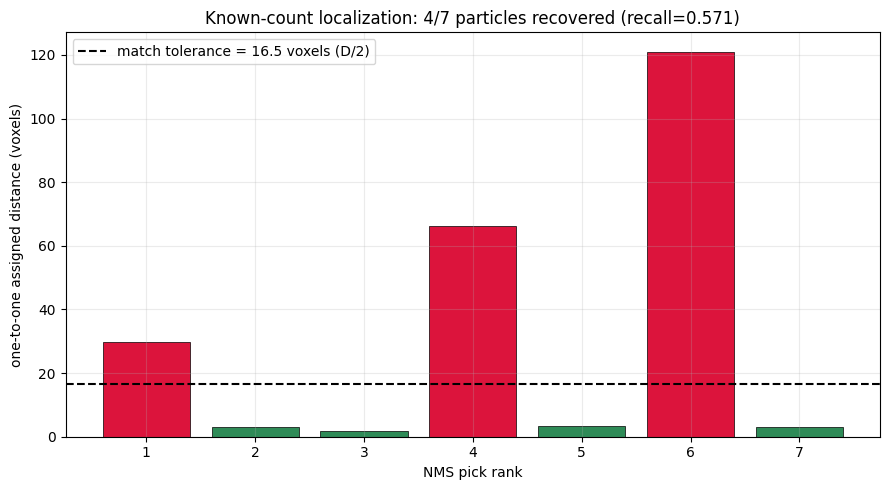

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = np.where(assignment["picked"], "seagreen", "crimson")
ax.bar(
    assignment["pick_rank"],
    assignment["distance_voxels"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.5,
)
ax.axhline(
    MATCH_TOLERANCE,
    color="black",
    linestyle="--",
    label=f"match tolerance = {MATCH_TOLERANCE:.1f} voxels (D/2)",
)
ax.set_xticks(assignment["pick_rank"])
ax.set_xlabel("NMS pick rank")
ax.set_ylabel("one-to-one assigned distance (voxels)")
ax.set_title(
    f"Known-count localization: {num_recovered}/{KNOWN_PARTICLE_COUNT} particles recovered "
    f"(recall={recall_at_known_count:.3f})"
)
ax.legend()
plt.tight_layout()

## NMS-radius recall sweep on the fixed score tensor

Reuse the already-computed likelihood tensor and rerun only spherical NMS. The only changed parameter is the suppression radius. For each radius, retain the known number of particles and report recall. Here `D` is the configured 33-voxel particle diameter; the values below are **NMS radii**, not full suppression-sphere diameters.

,NMS radius / D,NMS radius (voxels),particles recovered,recall
0,0.5,16.5,4,0.571
1,0.7,23.1,3,0.429
2,1.0,33.0,4,0.571


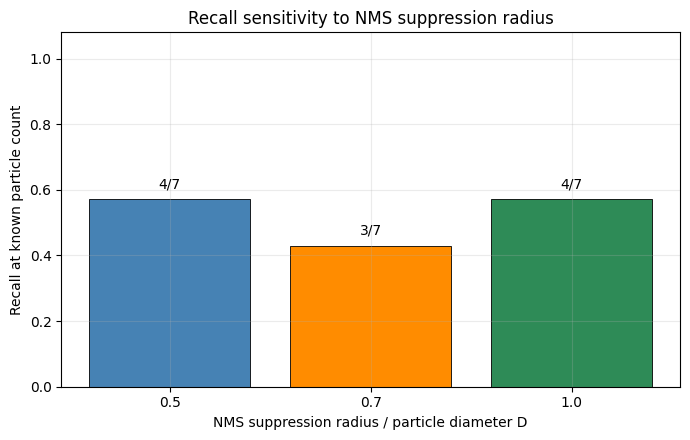

In [26]:
def recall_at_nms_radius(radius_factor):
    swept_picks = nms_ranked(
        score_np,
        radius=radius_factor * PARTICLE_DIAMETER_VOXELS,
        max_picks=KNOWN_PARTICLE_COUNT,
    )
    swept_assignment = known_count_assignment(
        swept_picks,
        gt,
        MATCH_TOLERANCE,
    )
    recovered = int(swept_assignment["picked"].sum())
    return recovered, recovered / KNOWN_PARTICLE_COUNT


nms_sweep_rows = []
for radius_factor in (0.5, 0.7, 1.0):
    recovered, recall = recall_at_nms_radius(radius_factor)
    nms_sweep_rows.append({
        "NMS radius / D": radius_factor,
        "NMS radius (voxels)": radius_factor * PARTICLE_DIAMETER_VOXELS,
        "particles recovered": recovered,
        "recall": recall,
    })

nms_sweep = pd.DataFrame(nms_sweep_rows)
display(nms_sweep.style.format({
    "NMS radius / D": "{:.1f}",
    "NMS radius (voxels)": "{:.1f}",
    "recall": "{:.3f}",
}))

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(
    nms_sweep["NMS radius / D"].astype(str),
    nms_sweep["recall"],
    color=["steelblue", "darkorange", "seagreen"],
    edgecolor="black",
    linewidth=0.6,
)
for bar, recovered in zip(bars, nms_sweep["particles recovered"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.025,
        f"{recovered}/{KNOWN_PARTICLE_COUNT}",
        ha="center",
        va="bottom",
    )
ax.set_ylim(0, 1.08)
ax.set_xlabel("NMS suppression radius / particle diameter D")
ax.set_ylabel("Recall at known particle count")
ax.set_title("Recall sensitivity to NMS suppression radius")
plt.tight_layout()

## Overlay high likelihood on the raw tomogram

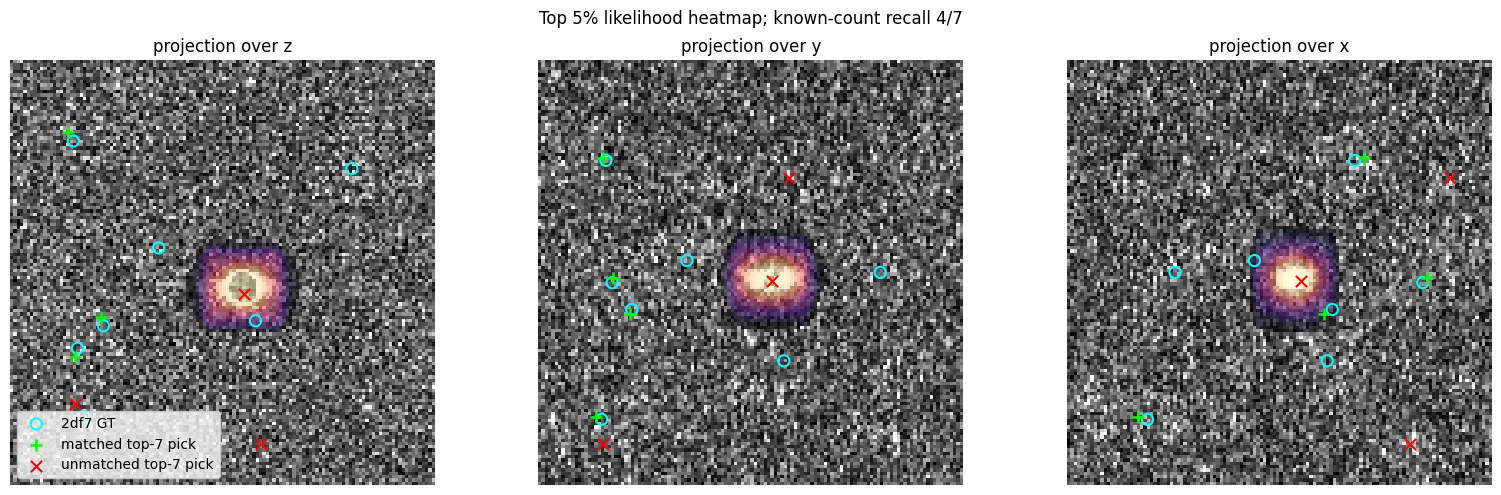

In [27]:
offset = TEMPLATE_SIZE // 2
score_on_roi = np.full(
    tomogram.shape,
    score_np.min(),
    dtype=np.float32,
)
score_on_roi[
    offset:offset + score_np.shape[0],
    offset:offset + score_np.shape[1],
    offset:offset + score_np.shape[2],
] = score_np

selected_picks = picks[:, :3]
matched_pick_mask = assignment["picked"].to_numpy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
raw_mips = [tomogram.max(axis=0), tomogram.max(axis=1), tomogram.max(axis=2)]
score_mips = [
    np.max(score_on_roi, axis=0),
    np.max(score_on_roi, axis=1),
    np.max(score_on_roi, axis=2),
]
gt_plot = [gt[:, [2, 1]], gt[:, [2, 0]], gt[:, [1, 0]]]
pick_plot = [
    selected_picks[:, [2, 1]],
    selected_picks[:, [2, 0]],
    selected_picks[:, [1, 0]],
]
titles = ["projection over z", "projection over y", "projection over x"]
for ax, raw, heat, gt2, pred2, title in zip(
    axes, raw_mips, score_mips, gt_plot, pick_plot, titles
):
    ax.imshow(robust_standardize(raw), cmap="gray")
    lo = np.percentile(heat, 95)
    overlay = np.ma.masked_where(heat < lo, heat)
    ax.imshow(overlay, cmap="magma", alpha=0.55)
    ax.scatter(gt2[:, 0], gt2[:, 1], s=65, facecolors="none",
               edgecolors="cyan", linewidths=1.5, label="2df7 GT")
    ax.scatter(pred2[matched_pick_mask, 0], pred2[matched_pick_mask, 1],
               marker="+", s=85, color="lime", linewidths=1.8,
               label="matched top-7 pick")
    ax.scatter(pred2[~matched_pick_mask, 0], pred2[~matched_pick_mask, 1],
               marker="x", s=65, color="red", linewidths=1.5,
               label="unmatched top-7 pick")
    ax.set_title(title)
    ax.axis("off")
axes[0].legend(loc="lower left")
plt.suptitle(
    f"Top 5% likelihood heatmap; known-count recall "
    f"{num_recovered}/{KNOWN_PARTICLE_COUNT}"
)
plt.tight_layout()

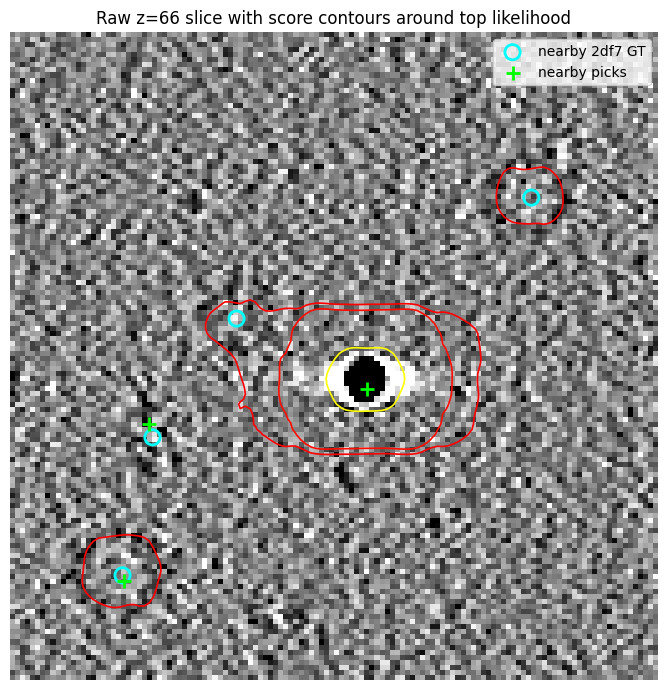

In [28]:
top_center = picks[0, :3].astype(int)
z = top_center[0]
raw_slice = tomogram[z]
score_slice = score_on_roi[z]

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(robust_standardize(raw_slice), cmap="gray")
levels = np.nanpercentile(score_slice, [90, 95, 99])
ax.contour(score_slice, levels=np.unique(levels), cmap="autumn", linewidths=1.2)
near_gt = gt[np.abs(gt[:, 0] - z) <= PARTICLE_DIAMETER_VOXELS / 2]
near_pick = selected_picks[
    np.abs(selected_picks[:, 0] - z) <= PARTICLE_DIAMETER_VOXELS / 2
]
ax.scatter(near_gt[:, 2], near_gt[:, 1], s=120, facecolors="none",
           edgecolors="cyan", linewidths=2, label="nearby 2df7 GT")
ax.scatter(near_pick[:, 2], near_pick[:, 1], marker="+", s=100,
           color="lime", linewidths=2, label="nearby picks")
ax.set_title(f"Raw z={z} slice with score contours around top likelihood")
ax.legend()
ax.axis("off")
plt.tight_layout()

## Final numerical checks

In [29]:
expanded_is_sorted = np.all(np.diff(template_eigvals) <= 0)
multiplets_complete = all(
    np.sum(template_orders == ell) % (2 * ell + 1) == 0
    for ell in np.unique(template_orders)
)

checks = pd.Series({
    "whitened values finite": np.isfinite(whitened_np).all(),
    "whitened mean near zero": abs(whitened_np.mean()) < 1e-6,
    "whitened Frobenius norm near one": abs(np.linalg.norm(whitened_np) - 1) < 1e-4,
    "Fredholm eigenvalues globally sorted": np.all(np.diff(flat_eigvals) <= 0),
    "expanded eigenvalues sorted": expanded_is_sorted,
    "spherical multiplets complete": multiplets_complete,
    "score values finite": np.isfinite(score_np).all(),
    "known number of picks returned": len(picks) == KNOWN_PARTICLE_COUNT,
    "at least one matched 2df7": num_recovered > 0,
})
display(checks.rename("passed").to_frame())
assert checks.all(), checks[~checks]

print(
    f"Known-count result: {num_recovered}/{KNOWN_PARTICLE_COUNT} target particles "
    f"recovered (recall={recall_at_known_count:.3f}) from exactly "
    f"{KNOWN_PARTICLE_COUNT} NMS picks."
)

,passed
whitened values finite,True
whitened mean near zero,True
whitened Frobenius norm near one,True
Fredholm eigenvalues globally sorted,True
expanded eigenvalues sorted,True
spherical multiplets complete,True
score values finite,True
known number of picks returned,True
at least one matched 2df7,True


Known-count result: 4/7 target particles recovered (recall=0.571) from exactly 7 NMS picks.


## Interpretation checklist

A healthy run should show:

- low-variance patches dominated by background noise;
- a calibrated noise RPSD whose integral matches the spatial noise estimate;
- a visibly flatter second-pass noise PSD after whitening;
- nonnegative, decaying Fredholm eigenvalues;
- complete `m=-ell,...,+ell` angular multiplets without zero templates;
- localized score peaks that overlap raw-density structures;
- the known number of NMS picks recovering as many ground-truth particles as possible;
- small one-to-one localization distances relative to the `D/2` match tolerance.

Poor final picking despite healthy intermediate checks would point toward a
model limitation—most importantly the isotropic covariance assumption in the
presence of the Cryo-ET missing wedge or contamination by other particle
classes—rather than a units or implementation failure.